<a href="https://colab.research.google.com/github/DaJeong03/voice-ai-study/blob/main/day06_pitch_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!apt-get install -y fonts-nanum
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


In [2]:
# 오디오 불러오기
y, sr = librosa.load(librosa.ex('trumpet'))
print(f"샘플레이트: {sr}Hz, 길이: {len(y)/sr:.2f}초")

샘플레이트: 22050Hz, 길이: 5.33초


In [3]:
# pyin 알고리즘으로 Pitch 추출
f0, voiced_flag, voiced_prob = librosa.pyin(
    y,
    fmin=librosa.note_to_hz('C2'),  # 최소 주파수 (약 65Hz)
    fmax=librosa.note_to_hz('C7')   # 최대 주파수 (약 2093Hz)
)

times = librosa.times_like(f0, sr=sr)
print(f"Pitch 배열 길이: {len(f0)}")
print(f"Pitch 범위: {np.nanmin(f0):.1f}Hz ~ {np.nanmax(f0):.1f}Hz")

Pitch 배열 길이: 230
Pitch 범위: 345.2Hz ~ 625.9Hz


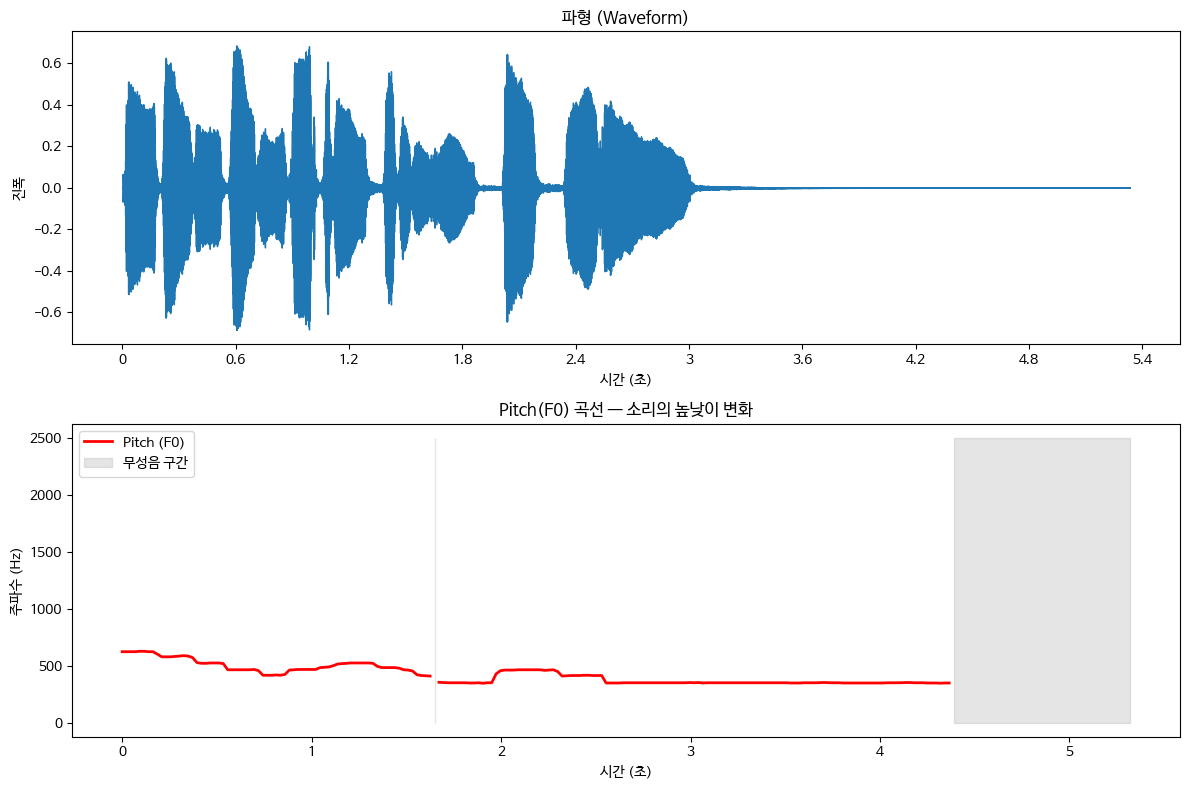

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# 위: 파형
librosa.display.waveshow(y, sr=sr, ax=axes[0])
axes[0].set_title("파형 (Waveform)")
axes[0].set_xlabel("시간 (초)")
axes[0].set_ylabel("진폭")

# 아래: Pitch 곡선
axes[1].plot(times, f0, color='red', linewidth=2, label='Pitch (F0)')
axes[1].set_title("Pitch(F0) 곡선 — 소리의 높낮이 변화")
axes[1].set_xlabel("시간 (초)")
axes[1].set_ylabel("주파수 (Hz)")
axes[1].legend()

# 소리 없는 구간 (무성음) 표시
axes[1].fill_between(times, 0, 2500,
                      where=~voiced_flag,
                      alpha=0.2, color='gray',
                      label='무성음 구간')
axes[1].legend()

plt.tight_layout()
plt.show()